In [1]:
import numpy as np
import matplotlib as mpl
# from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import f_oneway
import os
import time
from itertools import combinations

from dataeval.metrics.estimators import ber

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

from skl2onnx import to_onnx
from onnxruntime import InferenceSession

# hide the "y_pred contains classes not in y_true" UserWarning from sklearn as it is expected when using different definitions
from warnings import filterwarnings
filterwarnings("ignore",module="sklearn",category=UserWarning)
filterwarnings("ignore",module="dataeval",category=RuntimeWarning)

In [2]:
data_folder = 'vk_definitions\\csv_files'
weighted = True

In [3]:
LM_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and 'l&m' in x]

In [4]:
vk_region_colours = {
    'lipid': '#F5C308',
    'peptide': '#BD3A53',

    'carbohydrate': '#0040FF',
    'amino_sugar': '#7C9EBF',
    
    'lignin': '#33251E',
    'tannin': '#CE833B',

    'pah': "#808080",

    'unassigned': '#e6e6e6'
}

In [38]:
## Functions

def get_elements_from_formula(formula) -> dict:
    elements = {}
    current_element = ''
    current_count = ''
    for char in formula:
        if char.isupper():
            if current_element:
                elements[current_element] = int(current_count) if current_count else 1
            current_element = char
            current_count = ''
        elif char.islower():
            current_element += char
        elif char.isdigit():
            current_count += char
    if current_element:
        elements[current_element] = int(current_count) if current_count else 1
    return elements


def get_peptide_formula(sequence, amino_acids_dict) -> dict:
    total_elements = {}
    for aa in sequence:
        aa_elements = amino_acids_dict.get(aa, {})
        for element, count in aa_elements.items():
            total_elements[element] = total_elements.get(element, 0) + count
    return total_elements


def train_test(X, y,train_size=0.8,weighted_yn=weighted,random_state=5):
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_state)

    if weighted_yn:
        class_weights_train = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights_test = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)

        weights_dict_train = {cls: weight for cls, weight in zip(np.unique(y_train), class_weights_train)}
        weights_dict_test = {cls: weight for cls, weight in zip(np.unique(y_test), class_weights_test)}

        weights_train = np.array([weights_dict_train[cat] for cat in y_train])
        weights_test = np.array([weights_dict_test[cat] for cat in y_test])
    
    else:
        weights_train = None
        weights_test = None

    return X_train, X_test, y_train, y_test, weights_train, weights_test


def train_estimator(X, y, model='GNB', degree=3, probability=True):
    if model == 'GNB':
        return CalibratedClassifierCV(CalibratedClassifierCV(GaussianNB())).fit(X, y)
    
    elif model == 'SVM':
        return CalibratedClassifierCV(SVC(kernel="poly", degree=degree, C=100, gamma=1, probability=probability)).fit(X, y)


def draw_decision_boundary_plot(estimator, X, categories, xlabel, ylabel, title=None, savepath=None,
                                level_step=0.1,grid_resolution=500,colors_dict=None):
    fig, ax = plt.subplots()

    levels = np.arange(0, 1 + level_step, level_step) if level_step else None # levels for contour plots

    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="contourf", # contourf, contour, pcolormesh
        ax=ax,
        grid_resolution=grid_resolution,
        levels=levels,
        multiclass_colors=[colors_dict[cat] for cat in categories] if colors_dict else None
    )

    # for cs in disp.surface_:
    #     plt.clabel(cs, inline=False, fontsize=8,colors='#666')

    for cat in categories:
        cat_mod = cat.replace('_',' ').capitalize() + '-like'
        if 'Pah' in cat_mod:
            cat_mod = 'PAH-like'
        ax.scatter(None,None,zorder=1,alpha=1,label=cat_mod,c=colors_dict[cat] if colors_dict else None)

    if level_step:
        for level in np.arange(level_step, 1 + level_step, level_step):
            ax.plot([None,None],[None,None],
                    c='k',alpha=level,lw=10,label=f'{(100*level):.0f}% probability')
   
    ax.legend(framealpha=1,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,fontsize=12)

    ax.set_xlim(0,2.5)
    ax.set_ylim(0,2.5)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    if title: ax.set_title(title, fontsize=16)

    if savepath: fig.savefig(savepath, dpi = 600, facecolor = '#fff', bbox_inches='tight')

    # return disp


def test_model_accuracy(model,X,y,repeats=50, classifier_name='[DEFAULT]', title=None,
                        xlabel=None,ylabel=None,colors_dict=None):

    accuracies = []

    for i in range(repeats):
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = train_test(X, y,random_state=None)

        fitted_model = model.fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)

        accuracies.append(balanced_accuracy_score(y_true = y_rdm_test,
                                                y_pred = fitted_model.predict(X_rdm_test),
                                                sample_weight=weights_rdm_test if weighted else None,
                                                ))

        if accuracies[i] == np.max(accuracies):
            max_model = fitted_model
            X_rdm_train_best = X_rdm_train
            y_rdm_train_best = y_rdm_train

    print(f'''Average accuracy of the {classifier_name} classifier trained on {len(X_rdm_train)} samples (run {repeats} times): {np.mean(accuracies)} +/- {np.std(accuracies)}
Max accuracy: {np.max(accuracies)}
Min accuracy: {np.min(accuracies)}
Random Accuracy: {1/len(np.unique(y_rdm_train))}''')

    if np.shape(X)[1] == 2:
        draw_decision_boundary_plot(max_model,
                                    X_rdm_train_best,
                                    categories=np.unique(y_rdm_train_best),
                                    xlabel=xlabel,
                                    ylabel=ylabel,
                                    colors_dict=colors_dict,
                                    title=title
                                    )


def fitting_runtime(iterations:int,model,X,y,weights) -> float:

    times = []

    for i in range(iterations):
        start_time = time.time()
        fit = model.fit(X, y, sample_weight=weights)
        runtime = time.time() - start_time

        times.append(runtime)

    return sum(times)/iterations


def persist_model_onnx(clf, X, filepath):
    # https://scikit-learn.org/stable/model_persistence.html
    onx = to_onnx(clf, X[:1].astype(np.float32), target_opset=12)
    with open(filepath, "wb") as f:
        f.write(onx.SerializeToString())


def load_model_onnx(filepath):
    with open(filepath, "rb") as f:
        onx = f.read()
    sess = InferenceSession(onx, providers=["CPUExecutionProvider"])

    return sess


def molecclass(df:pd.DataFrame,areas:dict,dims=['O/C','H/C','N/C']) ->  np.ndarray:

    assignments = ['unassigned'] * len(df)

    for i in df[dims].index:
        ratios = df[dims].loc[i]

        for a in areas:
            counter = 0

            for d in dims:
                if ratios[d] >= np.min(areas[a][d]) and ratios[d] <= np.max(areas[a][d]):
                    counter += 1
        
            if counter == len(dims):
                assignments[i] = a
                break
    
    assignments = np.array(assignments)
    assignments[np.where(assignments == 'peptide1')] = 'peptide'
    assignments[np.where(assignments == 'peptide2')] = 'peptide'

    return assignments


def create_3D_mesh(data, model, dims, number_of_points=50) -> pd.DataFrame:
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Create a 3D meshgrid for decision boundary visualization.
    '''
    data=data.copy()
    meshes_2d={}
    for i in range(len(dims)):
        meshes_2d.update({f"{dims[i]}": np.linspace(np.min(data[:,i]), np.max(data[:,i]), number_of_points)})

    # create meshgrid
    meshes_3d = np.meshgrid(*[x for x in meshes_2d.values()],
                            indexing='ij')

    stacked_mesh = np.vstack([x.ravel() for x in meshes_3d]).T  

    mesh_df = pd.DataFrame(stacked_mesh, columns=dims)

    preds = model.predict_proba(stacked_mesh)
    argmax =np.argmax(preds, axis=1)

    mesh_df['category'] = model.classes_[argmax]
    # mesh_df['probability'] = preds[np.arange(stacked_mesh.shape[0]), argmax]

    return mesh_df.sort_values(by=['category']).reset_index(drop=True)

def DecisionBoundaryDisplay_3D(data, model, dims, alpha=.8, title=None, squareSize=10, number_of_points=50,
                               colours = vk_region_colours,
                               savepath=None,show=True):
    # https://www.kaggle.com/code/frankmollard/3d-decision-boundaries
    '''
    Visualize 3D decision boundaries using Plotly.
    '''
    data = data.copy()

    mesh_df = create_3D_mesh(data=data, model=model, dims=dims, number_of_points=number_of_points)

    vizList = []
    for compound_class in mesh_df['category'].unique():

        i = mesh_df['category'] == compound_class

        globals()[f"D_{compound_class}"]=go.Scatter3d(

            x = mesh_df.loc[i, dims[0]],
            y = mesh_df.loc[i, dims[1]],
            z = mesh_df.loc[i, dims[2]],

            name = f"{compound_class.capitalize().replace('Pah', 'PAH').replace('_',' ')}-like",

            hovertemplate = dims[0] + ': %{x} <br>' + \
                            dims[1] + ': %{y} <br>' + \
                            dims[2] + ': %{z} <br>' + \
                            'category: {0}'.format(compound_class),

            mode='markers',
            marker=dict(
                size=squareSize,
                color=colours[compound_class],           
                opacity=alpha,#*mesh_df.loc[i, 'probability'].to_numpy(),
                symbol='square'
            )
        )

        vizList.append(globals()[f"D_{compound_class}"]) 

    fig = go.Figure(data=vizList)

    camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

    fig.update_layout(
        scene_camera=camera,
        autosize=True,
        template="plotly_white",
        scene={
            "xaxis_title":dims[0],
            "yaxis_title":dims[1],
            "zaxis_title":dims[2]
        },
        width=900, height=800,
        showlegend=True,
        title = title if title else None
    )

    if show:
        fig.show()

    if savepath:
        fig.write_html(savepath)

def draw_boxplot(data_dict, ylabel, title=None, savepath=None,colours=[],ylim=None,hline=None):
    fig, ax = plt.subplots()

    labels = list(data_dict.keys())

    bplot = ax.boxplot(list(data_dict.values()),
                       medianprops=dict(color='k',ls='-'),
                       patch_artist=True,
                       showfliers=True)

    ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=45,ha='right')

    ax.set_ylabel(ylabel, fontsize=12)
    
    ylim = ylim if ylim else (np.round(np.floor(1e2*np.min(list(data_dict.values())))/1e2,1), 1)
    ax.set_ylim(ylim)

    ax.set_yticks(np.arange(np.round(np.floor(1e2*ylim[0])/1e2,1),ylim[1]+0.01, 0.1))
    ax.tick_params(axis='y', which='minor')

    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

    if len(colours)>0:
        if len(colours)==1:
            colours = colours * len(labels)
        assert len(colours)==len(labels), "Number of colours must match number of boxplots"
        for patch, colour in zip(bplot['boxes'], colours):
            patch.set_facecolor(colour)

    if hline:
        ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title:
        ax.set_title(title, fontsize=14)
    if savepath:
        fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

In [6]:
overall_df = pd.DataFrame()
amino_acids_dict = {}

for file in LM_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)

    # Further processing and analysis of df

    category = file.replace('.csv', '').replace('l&m-', '')

    # save the results with the category name

    if category == 'amino_acid':
        for letter in df['1-letter code']:
            amino_acids_dict[letter] = get_elements_from_formula(df['FORMULA'][df['1-letter code'] == letter].to_list()[0])
        
        category = 'peptide'
    
    df_slice = pd.DataFrame({'category':[category] * len(df)})
    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    try:
        df_slice['formula'] = df['FORMULA']

    except KeyError:
        if category == 'peptide':
            seqs = df['Sequence'].to_list()
            formula_dict_list = [get_peptide_formula(seq, amino_acids_dict) for seq in seqs]
            df_slice['formula'] = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in formula_dict_list]

        elif category == 'lignin':
            for element in atomic_dict.keys():
                if element in df.columns:
                    atomic_dict[element] = df[element].to_list()
                else:
                    atomic_dict[element] = [0] * len(df)
    
    if category != 'lignin':
        for formula in df_slice['formula']:
            elements = get_elements_from_formula(formula)
            for element in atomic_dict.keys():
                atomic_dict[element].append(elements.get(element, 0))
    
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)
    
    if len(overall_df) == 0:
        overall_df = df_slice
    else:
        overall_df = pd.concat([overall_df, df_slice], ignore_index=True)

# calculate elemental ratios
for element in atomic_dict.keys():
    if element != 'C':
        overall_df[f'{element}/C'] = overall_df[element] / overall_df['C']

In [7]:
# print the count for each category
print(overall_df['category'].value_counts())

# sort the dataframe by category
overall_df = overall_df.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


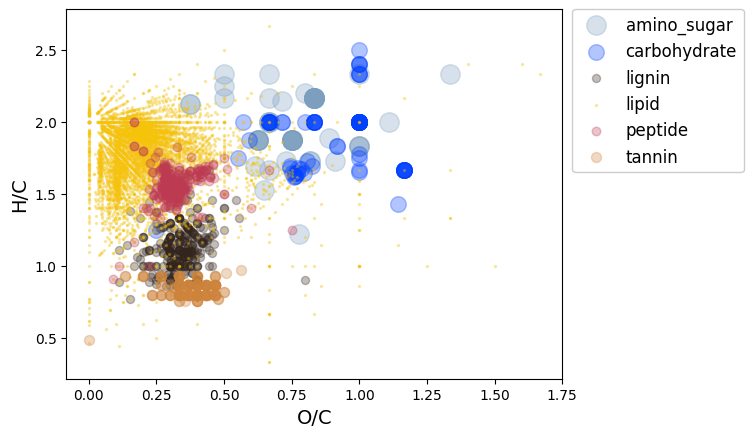

In [43]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in overall_df['category'].unique():
    subset = overall_df[overall_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category, c = vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df[overall_df['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig('vk_definitions\\plots\\vk_diagram.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')


In [9]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df['category']), y=overall_df['category'])
weights_dict = {cls: weight for cls, weight in zip(np.unique(overall_df['category']), class_weights)}

overall_df['weights'] = [weights_dict[cat] for cat in overall_df['category']]

In [10]:
overall_df.to_csv('vk_definitions\\new_vk_areas_df.csv', index=False)

In [12]:
wanted_columns = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X = overall_df[wanted_columns].to_numpy()
y = overall_df['category'].to_numpy()
weights = overall_df['weights'].to_numpy() if weighted else None
# Split the data into training and testing sets
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test(X, y)

bayes_error_rate = ber(X, y, method="MST")
max_acc = 1-bayes_error_rate.ber

multiclass_colors=[vk_region_colours[cat] for cat in np.unique(y)]

In [13]:
'''Only run this cell if you want to test any changes to the polynomial degree of the SVM classifier'''

# # choosing the degree of the polynomial kernel

# degrees = np.arange(1,11)
# accuracies = []

# for d in degrees:
#     accuracies.append(balanced_accuracy_score(y_true = y_test,
#                                               y_pred = CalibratedClassifierCV(SVC(kernel="poly",
#                                                                                       degree=d,
#                                                                                       C=100, gamma=1,
#                                                                                       class_weight='balanced' if weighted else None,
#                                                                                       probability=False)).fit(X=X_train, y=y_train, sample_weight=weights_train if weighted else None).predict(X_test),
#                                               sample_weight=weights_test if weighted else None,
#                                             ))
    
# fig, ax = plt.subplots()
# ax.plot(degrees,accuracies,marker='o')
# ax.set_xlabel('Polynomial kernel degree',fontsize=12)
# ax.set_ylabel('Accuracy',fontsize=12)
# ax.set_xticks(degrees)

# # draw horizontal line at max accuracy
# max_acc = np.max(accuracies)
# ax.axhline(y=max_acc, color='r', linestyle='--',zorder=-1,label=f'Max Accuracy: {np.round(max_acc,3)}')
# ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0, framealpha=1,fontsize=12)

# ax.set_title('SVM Classifier Accuracy vs Polynomial Kernel Degree\nfor Biochemical Compound Class Categories',fontsize=14)
# fig.savefig('vk_definitions\\plots\\svm_compound_class_accuracy_vs_polynomial_kernel_degree.svg',dpi = 600, facecolor = '#fff', bbox_inches='tight')

'Only run this cell if you want to test any changes to the polynomial degree of the SVM classifier'

In [14]:
poly_degree = 3

In [15]:
'''This cell takes 6 mins to run on my PC, so only run it if you want to tune the hyperparameters of the SVM classifier.
Results:
best_params_: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
best_estimator_: SVC(C=100, gamma=1)'''

# # choose C and gamma hyperparameters for SVM with polynomial kernel
# # https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/

# # without tuning
# model = SVC() 
# model.fit(X_train, y_train) 

# predictions = model.predict(X_test) 
# print('Results without tuning:\n', classification_report(y_test, predictions))

# # now tune

# param_grid = {'C': [10, 80, 100, 90, 1000], 
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
# 			'kernel': ['poly'],
#             }

# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
 
# grid.fit(X_train, y_train)

# print('best_params_:', grid.best_params_) 
# print('best_estimator_:', grid.best_estimator_)

"This cell takes 6 mins to run on my PC, so only run it if you want to tune the hyperparameters of the SVM classifier.\nResults:\nbest_params_: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}\nbest_estimator_: SVC(C=100, gamma=1)"

In [17]:
'''Only run if you want to test the accuracy of the classifiers. This takes a while as it runs 50 times for each classifier.'''

# # check accuracy of SVC and GNB trained on 80% of the data with polynomial kernel degree found earlier
# gnb = CalibratedClassifierCV(GaussianNB())
# svc_poly = CalibratedClassifierCV(SVC(kernel="poly",
#                                       C=10,
#                                       degree=poly_degree,
#                                       gamma=1,
#                                       probability=True))
# svc_rbf = CalibratedClassifierCV(SVC(kernel="rbf",
#                                      C=100, gamma=1,
#                                      probability=True))

# test_model_accuracy(gnb,X,y, classifier_name='GNB',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)
# test_model_accuracy(svc_poly,X,y, classifier_name='poly SVC',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)
# test_model_accuracy(svc_rbf,X,y, classifier_name='rbf SVC',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)

'Only run if you want to test the accuracy of the classifiers. This takes a while as it runs 50 times for each classifier.'

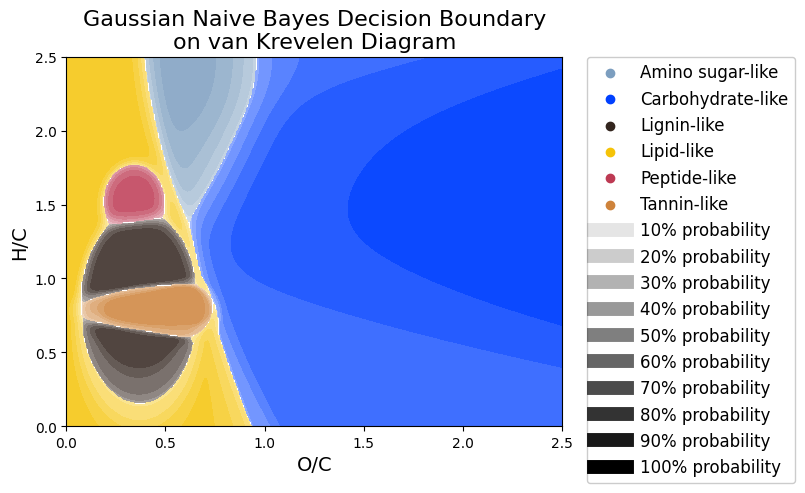

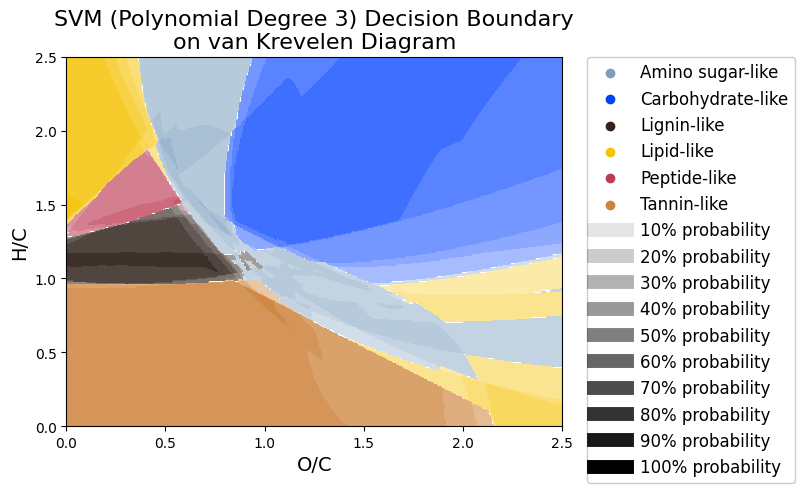

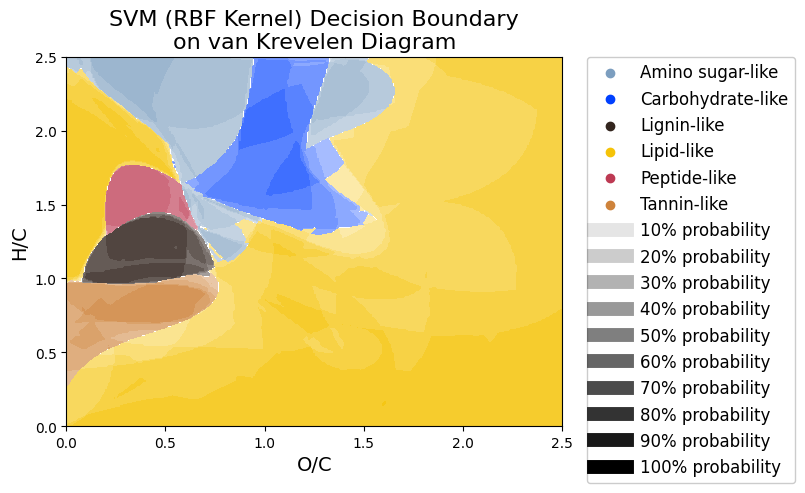

In [18]:
# train both classifiers with the entire dataset
gnb_overall = CalibratedClassifierCV(GaussianNB()).fit(X, y, sample_weight=weights if weighted else None)
svc_poly_overall = CalibratedClassifierCV(SVC(kernel="poly",degree=poly_degree,gamma='auto',probability=True)).fit(X, y, sample_weight=weights if weighted else None)
svc_rbf_overall = CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1, probability=True)).fit(X, y, sample_weight=weights if weighted else None)

disp = draw_decision_boundary_plot(gnb_overall,
                            X,
                            categories=np.unique(y),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title='Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\gnb_vk_decision_boundary.svg',
                            colors_dict=vk_region_colours
                            )

draw_decision_boundary_plot(svc_poly_overall,
                            X,
                            categories=np.unique(y),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title=f'SVM (Polynomial Degree {poly_degree}) Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\svc_poly_vk_decision_boundary.svg',
                            colors_dict=vk_region_colours
                            )

draw_decision_boundary_plot(svc_rbf_overall,
                            X,
                            categories=np.unique(y),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title=f'SVM (RBF Kernel) Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\svc_rbf_vk_decision_boundary.svg',
                            colors_dict=vk_region_colours
                            )

In [19]:
# use more dimensions to train the classifiers on a random train-test split and on the entire dataset
wanted_columns_more = ['O/C','H/C','N/C']
X_more_dims = overall_df[wanted_columns_more].to_numpy()

bayes_error_rate_more = ber(X_more_dims, y, method="MST")
max_acc_more = 1-bayes_error_rate_more.ber

In [20]:
# test_model_accuracy(CalibratedClassifierCV(GaussianNB()),X_more_dims,y, classifier_name='GNB',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)
# test_model_accuracy(CalibratedClassifierCV(SVC(kernel="poly",degree=poly_degree,gamma='auto',probability=True)),X_more_dims,y, classifier_name='poly SVC',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)
# test_model_accuracy(CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1, probability=True)),X_more_dims,y, classifier_name='rbf SVC',xlabel=wanted_columns[0],ylabel=wanted_columns[1],colors_dict=vk_region_colours)

In [25]:
# train both classifiers with the entire dataset
gnb_more_dims_all = CalibratedClassifierCV(GaussianNB()).fit(X_more_dims, y, sample_weight=weights if weighted else None)
svc_poly_more_dims_all = CalibratedClassifierCV(SVC(kernel="poly",
                                               degree=poly_degree,
                                               C=100, gamma=1,
                                               probability=True)).fit(X_more_dims, y, sample_weight=weights if weighted else None)
svc_rbf_more_dims_all = CalibratedClassifierCV(SVC(kernel="rbf",
                                              C=100,
                                              gamma=1,
                                              probability=True)).fit(X_more_dims, y, sample_weight=weights if weighted else None)

rndm_accuracy = 1/len(np.unique(y))

# test model accuracy with the new dimensions
print(f'''Accuracy of the Gaussian Naive Bayes classifier trained on {len(X_more_dims)} samples (dimensions:{', '.join(wanted_columns_more)}): {balanced_accuracy_score(y_true = y,
                                                                                                                                          y_pred = gnb_more_dims_all.predict(X_more_dims),
                                                                                                                                          sample_weight=weights if weighted else None,
                                                                                                                                          )
                                                                                                                    } 

Accuracy of the SVC classifier (Polynomial Degree {poly_degree}) trained on {len(X_more_dims)} samples (dimensions:{', '.join(wanted_columns_more)}): {balanced_accuracy_score(y_true = y,
                                                                                                                                                           y_pred = svc_poly_more_dims_all.predict(X_more_dims),
                                                                                                                                                           sample_weight=weights if weighted else None,
                                                                                                                                                           )
                                                                                                                                    }

Accuracy of the SVC classifier (RBF Kernel) trained on {len(X_more_dims)} samples (dimensions:{', '.join(wanted_columns_more)}): {balanced_accuracy_score(y_true = y,
                                                                                                                                                           y_pred = svc_rbf_more_dims_all.predict(X_more_dims),
                                                                                                                                                           sample_weight=weights if weighted else None,
                                                                                                                                                           )
                                                                                                                                    }

Random Accuracy: {rndm_accuracy}''')


Accuracy of the Gaussian Naive Bayes classifier trained on 5991 samples (dimensions:O/C, H/C, N/C): 0.905593452510606 

Accuracy of the SVC classifier (Polynomial Degree 3) trained on 5991 samples (dimensions:O/C, H/C, N/C): 0.9532462006565492

Accuracy of the SVC classifier (RBF Kernel) trained on 5991 samples (dimensions:O/C, H/C, N/C): 0.9544599194076406

Random Accuracy: 0.16666666666666666


In [26]:
'''# get the runtime of the NGB and SVC classifiers with more dimensions
iterations = 20

gnb_runtime = fitting_runtime(iterations, CalibratedClassifierCV(GaussianNB()), X_more_dims, y, weights if weighted else None)
svc_runtime = fitting_runtime(iterations, CalibratedClassifierCV(SVC(kernel="poly",
                                                  degree=poly_degree,
                                                  C=100, gamma=1,
                                                  probability=True)), X_more_dims, y, weights if weighted else None)

print(f'Gaussian Naive Bayes training runtime with more dimensions (iterations = {iterations}): {(gnb_runtime*1e3):.2f} ms')
print(f'SVC (Polynomial Degree {poly_degree}) training runtime with more dimensions (iterations = {iterations}): {(svc_runtime*1e3):.2f} ms')
print(f'SVC / GNB runtime = {(svc_runtime/gnb_runtime):.0f}')'''

'# get the runtime of the NGB and SVC classifiers with more dimensions\niterations = 20\n\ngnb_runtime = fitting_runtime(iterations, CalibratedClassifierCV(GaussianNB()), X_more_dims, y, weights if weighted else None)\nsvc_runtime = fitting_runtime(iterations, CalibratedClassifierCV(SVC(kernel="poly",\n                                                  degree=poly_degree,\n                                                  C=100, gamma=1,\n                                                  probability=True)), X_more_dims, y, weights if weighted else None)\n\nprint(f\'Gaussian Naive Bayes training runtime with more dimensions (iterations = {iterations}): {(gnb_runtime*1e3):.2f} ms\')\nprint(f\'SVC (Polynomial Degree {poly_degree}) training runtime with more dimensions (iterations = {iterations}): {(svc_runtime*1e3):.2f} ms\')\nprint(f\'SVC / GNB runtime = {(svc_runtime/gnb_runtime):.0f}\')'

In [27]:
DecisionBoundaryDisplay_3D(X_more_dims, gnb_more_dims_all, dims=wanted_columns_more,
                           title="Naive Bayes Decision Boundary 3D",savepath='vk_definitions\\plots\\gnb_3d_vk_decision_boundary.html',show=False)
DecisionBoundaryDisplay_3D(X_more_dims, svc_poly_more_dims_all, dims=wanted_columns_more,
                           title="SVC Polynomial Decision Boundary 3D",savepath='vk_definitions\\plots\\svc_poly_3d_vk_decision_boundary.html',show=False)
DecisionBoundaryDisplay_3D(X_more_dims, svc_rbf_more_dims_all, dims=wanted_columns_more,
                           title="SVC RBF Decision Boundary 3D",savepath='vk_definitions\\plots\\svc_rbf_3d_vk_decision_boundary.html',show=False)

In [28]:
# save the models
persist_model_onnx(gnb_more_dims_all, X_more_dims, "vk_definitions\\models\\gnb.onnx")
persist_model_onnx(svc_poly_more_dims_all, X_more_dims, "vk_definitions\\models\\svc_poly.onnx")
persist_model_onnx(svc_rbf_more_dims_all, X_more_dims, "vk_definitions\\models\\svc_rbf.onnx")

In [ ]:
# load the models
sess_gnb = load_model_onnx("vk_definitions\\models\\gnb.onnx")
sess_svc_poly = load_model_onnx("vk_definitions\\models\\svc_poly.onnx")
sess_svc_rbf = load_model_onnx("vk_definitions\\models\\svc_rbf.onnx")

# predict from onnx models
pred_sess_gnb = sess_gnb.run(None, {"X": X_more_dims.astype(np.float32)})
pred_sess_svc_poly = sess_svc_poly.run(None, {"X": X_more_dims.astype(np.float32)})
pred_sess_svc_rbf = sess_svc_rbf.run(None, {"X": X_more_dims.astype(np.float32)})
print(f'GNB: {pred_sess_gnb}')
print(f'SVC poly: {pred_sess_svc_poly}')
print(f'SVC RBF: {pred_sess_svc_rbf}')

model_combinations = list(combinations([{'GNB':pred_sess_gnb[0]},{'SVC_poly':pred_sess_svc_poly[0]},{'SVC_rbf':pred_sess_svc_rbf[0]}], 2))

# calculate the agreement between the ONNX model predictions
for combo in model_combinations:
    keys = list(combo[0].keys()) + list(combo[1].keys())
    preds1 = combo[0][keys[0]]
    preds2 = combo[1][keys[1]]
    agreement = np.sum(preds1 == preds2) / len(preds1)
    print(f'Agreement between {keys[0]} and {keys[1]} ONNX model predictions: {agreement}')

GNB: [array(['amino_sugar', 'amino_sugar', 'amino_sugar', ..., 'tannin',
       'tannin', 'tannin'], shape=(5991,), dtype=object), [{'amino_sugar': 0.8903179168701172, 'carbohydrate': 0.02166181243956089, 'lignin': 0.01396789401769638, 'lipid': 0.04788621515035629, 'peptide': 0.012766644358634949, 'tannin': 0.013399472460150719}, {'amino_sugar': 0.88958740234375, 'carbohydrate': 0.021695386618375778, 'lignin': 0.013957981951534748, 'lipid': 0.04859144240617752, 'peptide': 0.012768449261784554, 'tannin': 0.013399365358054638}, {'amino_sugar': 0.88958740234375, 'carbohydrate': 0.02169538475573063, 'lignin': 0.013957981951534748, 'lipid': 0.04859144240617752, 'peptide': 0.012768447399139404, 'tannin': 0.013399365358054638}, {'amino_sugar': 0.8903179168701172, 'carbohydrate': 0.02166181430220604, 'lignin': 0.01396789401769638, 'lipid': 0.04788621887564659, 'peptide': 0.012766644358634949, 'tannin': 0.013399472460150719}, {'amino_sugar': 0.8903179168701172, 'carbohydrate': 0.021661812439560

In [30]:
# comparison of these models with literature models

In [21]:
rivasubach_areas = { # van Krevelen diagram regions from Rivas-Ubach et al. 2018
                'carbohydrate':    {'O/C': [.8,50],     'H/C': [1.65,2.7],   'N/C': [-1,0]        }, #[[O/C_min,O/C_max],[H/C_min,H/C_max]]
                'lipid':           {'O/C': [-1,0.6],    'H/C': [1.32,50],    'N/C': [-1,0.126]    }, # -1 indicates is used to include 0; 50 is used to include +infinity
                'phytochemical':   {'O/C': [-1,1.15],   'H/C': [-1,1.32],    'N/C': [-1,.2]       },
                'amino_sugar':     {'O/C': [.61,50],    'H/C': [1.45,50],    'N/C': [0.07,0.2]    }, #a third item to indicate that this class contains N (put N/C ratio)
                'peptide1':        {'O/C': [.12,.6],    'H/C': [.9,2.5],     'N/C': [0.126,0.7]   },
                'peptide2':        {'O/C': [.6,1],      'H/C': [1.2,2.5],    'N/C': [0.2,0.7]     },
}

laszakovits_mackay_areas = { # van Krevelen diagram regions from Laszakovits and MacKay 2022
            'amino_sugar':     {'O/C': [.5,.91],    'H/C': [1.69,2.33],   },
            'carbohydrate':    {'O/C': [.55,1.17],  'H/C': [1.43,2]       },
            'lipid':           {'O/C': [.02,.37],   'H/C': [1.16,2.33]    },
            'lignin':          {'O/C': [.11,.42],   'H/C': [.77,1.33]     },
            'tannin':          {'O/C': [.13,.81],   'H/C': [.68,1.18]     },
            'peptide':         {'O/C': [.09,.75],   'H/C': [.91,2]        },
}

# adjust Rivas-Ubach et al. 2018 categories to match the categories in our dataset by replacing 'phytochemical' with 'lignin' and 'tannin' based on O/C and H/C ratios from Laszakovits and MacKay 2022
ru_lm_areas = { # van Krevelen diagram regions from Rivas-Ubach et al. 2018
                'carbohydrate':    {'O/C': [.8,50],     'H/C': [1.65,2.7],   'N/C': [-1,0]        }, #[[O/C_min,O/C_max],[H/C_min,H/C_max]]
                'lipid':           {'O/C': [-1,0.6],    'H/C': [1.32,50],    'N/C': [-1,0.126]    }, # -1 indicates is used to include 0; 50 is used to include +infinity
                'tannin':          {'O/C': [.13,.81],   'H/C': [.68,1.18],   'N/C': [-1,0]        },
                'lignin':          {'O/C': [.11,.42],   'H/C': [.77,1.33],   'N/C': [-1,0]        },
                'amino_sugar':     {'O/C': [.61,50],    'H/C': [1.45,50],    'N/C': [0.07,0.2]    }, #a third item to indicate that this class contains N (put N/C ratio)
                'peptide1':        {'O/C': [.12,.6],    'H/C': [.9,2.5],     'N/C': [0.126,0.7]   },
                'peptide2':        {'O/C': [.6,1],      'H/C': [1.2,2.5],    'N/C': [0.2,0.7]     },
}

In [22]:
rivas_ubach_adj_cat = overall_df['category'].copy().to_numpy()
rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == 'tannin')] = 'phytochemical'
rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == 'lignin')] = 'phytochemical'

rivas_ubach_class_weights = compute_class_weight('balanced', classes=np.unique(rivas_ubach_adj_cat), y=rivas_ubach_adj_cat)
rivas_ubach_class_weights_dict = {cls: weight for cls, weight in zip(np.unique(rivas_ubach_adj_cat), rivas_ubach_class_weights)}
rivas_ubach_weights = [rivas_ubach_class_weights_dict[cat] for cat in rivas_ubach_adj_cat]

rivas_ubach_bayes_error_rate = ber(X_more_dims, rivas_ubach_adj_cat, method="MST")
rivas_ubach_max_acc = 1-rivas_ubach_bayes_error_rate.ber

print(f'''Accuracy of the literature definitions on all dimensions ({len(X_more_dims)} samples):

                 
Balanced accuracy scores using Rivas-Ubach et al. 2018 definitions: {balanced_accuracy_score(y_true = rivas_ubach_adj_cat,
                                                                                             y_pred = molecclass(overall_df,areas=rivasubach_areas),
                                                                                             sample_weight = rivas_ubach_weights if weighted else None)
                                                                    }
% unassigned molecules with Rivas-Ubach et al. 2018 definitions: {100 * np.sum(molecclass(overall_df,areas=rivasubach_areas) == 'unassigned') / len(overall_df)}%

Balanced accuracy scores using Laszakovits and MacKay 2022 definitions: {balanced_accuracy_score(y_true = overall_df['category'].to_numpy(),
                                                                                                 y_pred = molecclass(overall_df,areas=laszakovits_mackay_areas,dims=['O/C','H/C']),
                                                                                                 sample_weight = weights if weighted else None)
                                                                        }
% unassigned molecules with Laszakovits and MacKay 2022 definitions: {100 * np.sum(molecclass(overall_df,areas=laszakovits_mackay_areas,dims=['O/C','H/C']) == 'unassigned') / len(overall_df)}%

Balanced accuracy scores using adjusted Rivas-Ubach et al. 2018 definitions with phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022: {balanced_accuracy_score(y_true = overall_df['category'].to_numpy(),
                                                                                                                                                                                                    y_pred = molecclass(overall_df,areas=ru_lm_areas),
                                                                                                                                                                                                    sample_weight = weights if weighted else None)
                                                }
% unassigned molecules with adjusted Rivas-Ubach et al. 2018 definitions with phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022: {100 * np.sum(molecclass(overall_df,areas=ru_lm_areas) == 'unassigned') / len(overall_df)}%

Random Accuracy: {1/len(np.unique(rivas_ubach_adj_cat))}''')

Accuracy of the literature definitions on all dimensions (5991 samples):


Balanced accuracy scores using Rivas-Ubach et al. 2018 definitions: 0.8441893835136082
% unassigned molecules with Rivas-Ubach et al. 2018 definitions: 1.101652478718077%

Balanced accuracy scores using Laszakovits and MacKay 2022 definitions: 0.541211914926922
% unassigned molecules with Laszakovits and MacKay 2022 definitions: 4.640293773994324%

Balanced accuracy scores using adjusted Rivas-Ubach et al. 2018 definitions with phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022: 0.746638575948257
% unassigned molecules with adjusted Rivas-Ubach et al. 2018 definitions with phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022: 3.455182774161242%

Random Accuracy: 0.2


In [23]:
# fit a gnb using the rivas ubach adjusted categories

rivas_ubach_X_train, rivas_ubach_X_test, rivas_ubach_y_train, rivas_ubach_y_test, \
    rivas_ubach_weights_train, rivas_ubach_weights_test = train_test(X_more_dims, rivas_ubach_adj_cat)

gnb_ru_adj = CalibratedClassifierCV(GaussianNB()).fit(rivas_ubach_X_train, rivas_ubach_y_train, sample_weight=rivas_ubach_weights_train if weighted else None)
svc_ru_adj = CalibratedClassifierCV(SVC(kernel="poly", degree=poly_degree, C=100, gamma=1)).fit(rivas_ubach_X_train, rivas_ubach_y_train, sample_weight=rivas_ubach_weights_train if weighted else None)

test_model_accuracy(CalibratedClassifierCV(GaussianNB()),X_more_dims,rivas_ubach_adj_cat, classifier_name='GNB - Rivas-Ubach adj',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)
test_model_accuracy(CalibratedClassifierCV(SVC(kernel="poly", degree=poly_degree, C=100, gamma=1)),X_more_dims,rivas_ubach_adj_cat, classifier_name='SVC - Polynomial - Rivas-Ubach adj',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)                                                                                                                                                                                           
test_model_accuracy(CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1)),X_more_dims,rivas_ubach_adj_cat, classifier_name='SVC - RBF - Rivas-Ubach adj',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)                                                                                                                                                                                           

Average accuracy of the GNB - Rivas-Ubach adj classifier trained on 4792 samples (run 50 times): 0.9160137219837367 +/- 0.02025586901348613
Max accuracy: 0.9497027835854543
Min accuracy: 0.8619325710033673
Random Accuracy: 0.2


KeyboardInterrupt: 

In [24]:
# test the model accuracies using the same slices of the overall dataset and plot boxplots and do ANOVA on the results

clf_models = {
    'GNB': CalibratedClassifierCV(GaussianNB()),
    'SVC (Polynomial)': CalibratedClassifierCV(SVC(kernel="poly", degree=poly_degree, gamma='auto')),
    'SVC (RBF)': CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1)),
}

lit_models = {
    'Laszakovits & MacKay': laszakovits_mackay_areas,
    'Adjusted Rivas-Ubach': ru_lm_areas,
}

phyto_clf_models = {f'{x} (Rivas-Ubach)' : clf_models[x] for x in clf_models}
phyto_lit_model = {
    'Rivas-Ubach': rivasubach_areas,
}

models_list = list(lit_models.keys()) + list(clf_models.keys()) + list(phyto_lit_model.keys()) + list(phyto_clf_models.keys())

accuracies_dict = {name: [] for name in models_list}
balanced_accuracies_dict = {name: [] for name in models_list}

repeats = 200

columns = wanted_columns_more

for n in range(repeats):
    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = train_test(X_more_dims, y,random_state=None)

    for model in clf_models:
        clf = clf_models[model].fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict[model].append(balanced_acc)
    
    for model in lit_models:

        cols = wanted_columns_more if 'Laszakovits' not in model else wanted_columns

        y_pred = molecclass(pd.DataFrame(X_rdm_test, columns=wanted_columns_more), areas=lit_models[model], dims=cols)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)
        
        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        balanced_accuracies_dict[model].append(balanced_acc)

    # phytochemical replaced by lignin and tannin definitions from Laszakovits and MacKay 2022
    X_rdm_train_phyto, X_rdm_test_phyto, y_rdm_train_phyto, y_rdm_test_phyto, \
    weights_rdm_train_phyto, weights_rdm_test_phyto = train_test(X_more_dims, rivas_ubach_adj_cat,random_state=None)

    for model in phyto_clf_models:
        clf = phyto_clf_models[model].fit(X_rdm_train_phyto, y_rdm_train_phyto, sample_weight=weights_rdm_train_phyto if weighted else None)
        y_pred = clf.predict(X_rdm_test_phyto)

        acc = accuracy_score(y_true=y_rdm_test_phyto,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test_phyto,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test_phyto if weighted else None)
        
        balanced_accuracies_dict[model].append(balanced_acc)
        
    for model in phyto_lit_model:

        y_pred = molecclass(pd.DataFrame(X_rdm_test_phyto, columns=wanted_columns_more), areas=phyto_lit_model[model], dims=wanted_columns_more)
        
        acc = accuracy_score(y_true=y_rdm_test_phyto,
                             y_pred=y_pred,
                             normalize=True)
        accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test_phyto,
                                      y_pred=y_pred,
                                      sample_weight=weights_rdm_test_phyto if weighted else None)
        
        balanced_accuracies_dict[model].append(balanced_acc)

In [25]:
# adjust accuracies_dict values by the chance of random guessing
chance_balanced_accuracies_dict = {}

for key in balanced_accuracies_dict:
    number_of_categories = len(np.unique(y)) if key not in list(phyto_lit_model.keys()) + list(phyto_clf_models.keys()) else len(np.unique(rivas_ubach_adj_cat))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict[key] ]

In [26]:
comparison_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in models_list],
    'mean_accuracy':[np.mean(accuracies_dict[model]) for model in models_list],
    'std_accuracy':[np.std(accuracies_dict[model]) for model in models_list],
    'median_accuracy':[np.median(accuracies_dict[model]) for model in models_list],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict[model]) for model in models_list],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict[model]) for model in models_list],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict[model]) for model in models_list],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict[model]) for model in models_list],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict[model]) for model in models_list],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict[model]) for model in models_list],
})

comparison_df.to_csv('vk_definitions\\model_performance_comparison.csv', index=False)

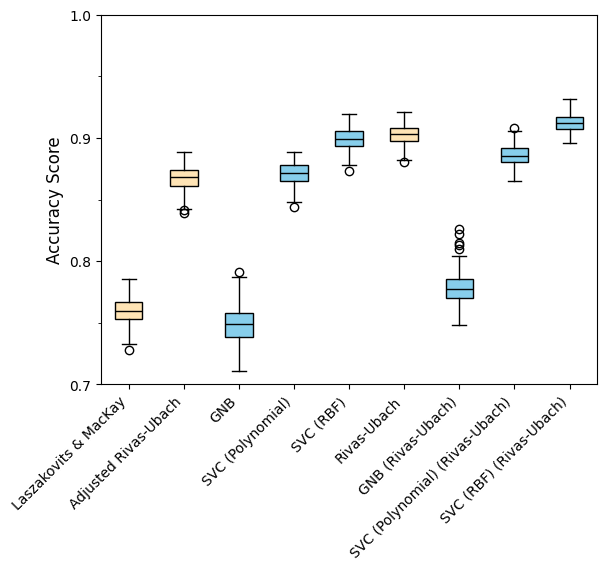

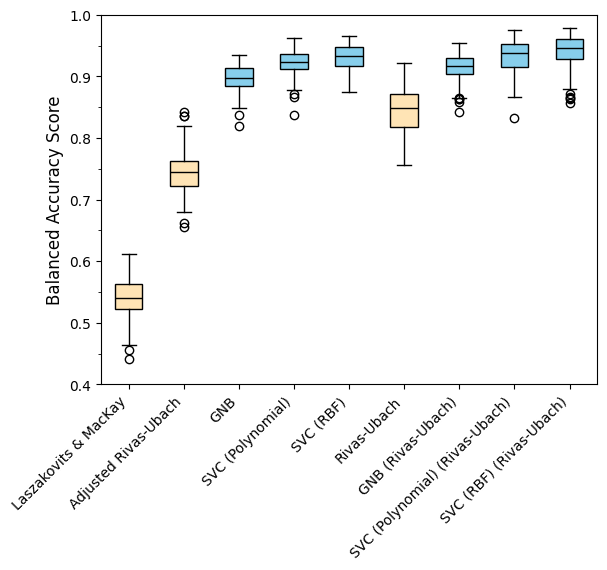

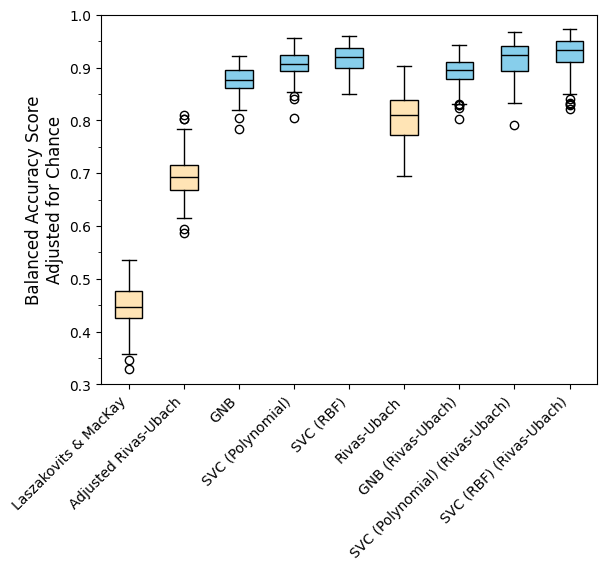

In [27]:
boxplot_colors = []
for model in models_list:
    if model in clf_models or model in phyto_clf_models:
        boxplot_colors.append('skyblue')
    elif model in lit_models or model in phyto_lit_model:
        boxplot_colors.append('moccasin')

# draw a boxplot comparing the "raw" accuracies of the different models
draw_boxplot(accuracies_dict,
             ylabel='Accuracy Score',
             colours=boxplot_colors,
            #  ylim=(0.65,1),
             savepath='vk_definitions\\plots\\comparison_boxplot_raw.svg')

# draw a boxplot comparing the balanced accuracies of the different models
draw_boxplot(balanced_accuracies_dict,
             ylabel='Balanced Accuracy Score',
             colours=boxplot_colors,
            #  ylim=(0.35,1),
             savepath='vk_definitions\\plots\\comparison_boxplot.svg')

# draw a boxplot comparing the accuracies of the different models with the accuracies adjusted by random guessing
draw_boxplot(chance_balanced_accuracies_dict,
             ylabel='Balanced Accuracy Score\nAdjusted for Chance',
             colours=boxplot_colors,
            #  ylim=(0.3,1),
             savepath='vk_definitions\\plots\\comparison_boxplot_adjusted.svg')

In [ ]:
# size effect means that with large sample sizes, even small differences can be statistically significant, so the following code is commented out

# # calculate the p value using the f_oneway function from scipy.stats between all pairs of models
# p_dict = {}
# for comb in list(combinations(labels,2)):
#     p_dict[f'{comb[0]},{comb[1]}'] = f_oneway(*[balanced_accuracies_dict[comb[0]],balanced_accuracies_dict[comb[1]]],nan_policy='omit')[1]

# # draw a binary correlation matrix plot of the p values and colour only the values < 0.05

# threshold = 0.05

# p_matrix = pd.DataFrame(np.ones((len(labels),len(labels))), index=labels, columns=labels)
# p_matrix[p_matrix == 1] = np.nan
# for comb in list(combinations(labels,2)):
#     p_value = p_dict[f'{comb[0]},{comb[1]}']
#     p_matrix.loc[comb[0], comb[1]] = np.nan
#     p_matrix.loc[comb[1], comb[0]] = p_value

# p_matrix[(p_matrix > threshold)&(p_matrix.notna())] = 1
# p_matrix[(p_matrix <= threshold)&(p_matrix.notna())] = 0

# fig_corr, ax_corr = plt.subplots()

# colours = ['tab:orange', 'tab:blue'] # first colour for p <= threshold (significant difference), second for p > threshold (not significant difference)

# cmap = mpl.colors.ListedColormap(colours)

# cax = ax_corr.matshow(p_matrix, cmap=cmap)

# for label, colour in zip([f'$p\\leq{threshold}$', f'$p>{threshold}$'], colours):
#     ax_corr.scatter([], [], c=colour, label=label,marker='s',s=100)

# ax_corr.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)


# ax_corr.set_xticks(np.arange(len(labels)-1), labels[:-1], rotation=45,horizontalalignment='right')
# ax_corr.set_yticks(np.arange(1,len(labels)), labels[1:])
# ax_corr.xaxis.set_ticks_position('bottom')
# ax_corr.set_xlim(-0.5, len(labels)-1.5)
# ax_corr.set_ylim(len(labels)-0.5, 0.5)

# fig_corr.savefig('vk_definitions\\plots\\comparison_correlation_matrix.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

In [30]:
# include PAHs in the dataset

all_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and x not in LM_files]

In [31]:
overall_df_complete = pd.DataFrame()

for file in all_files:
    df = pd.read_csv(os.path.join(data_folder, file))

    category = file.replace('.csv', '')

    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    df_slice = pd.DataFrame({'category':[category] * len(df)})
    df_slice['formula'] = df['FORMULA']

    for formula in df_slice['formula']:
        elements = get_elements_from_formula(formula)

        for element in atomic_dict.keys():
            atomic_dict[element].append(elements.get(element, 0))

    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    for element in atomic_dict.keys():
        if element != 'C':
            df_slice[f'{element}/C'] = df_slice[element] / df_slice['C']
    
    overall_df_complete = pd.concat([overall_df, df_slice], ignore_index=True) if len(overall_df_complete) == 0 else pd.concat([overall_df_complete, df_slice], ignore_index=True)

# print the count for each category
print(overall_df_complete['category'].value_counts())

# sort the dataframe by category
overall_df_complete = overall_df_complete.sort_values(by=['category']).reset_index(drop=True)


category
lipid           5109
lignin           297
peptide          263
tannin           192
pah               86
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


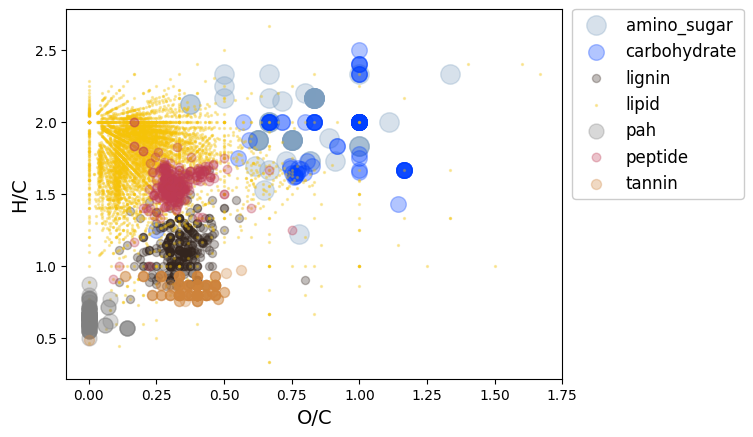

In [42]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in overall_df_complete['category'].unique():
    subset = overall_df_complete[overall_df_complete['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category, c=vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df_complete[overall_df_complete['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig('vk_definitions\\plots\\vk_diagram_complete.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

In [33]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df_complete['category']), y=overall_df_complete['category'])
weights_dict_complete = {cls: weight for cls, weight in zip(np.unique(overall_df_complete['category']), class_weights)}

overall_df_complete['weights'] = [weights_dict_complete[cat] for cat in overall_df_complete['category']]

overall_df_complete.to_csv('vk_definitions\\new_vk_areas_complete_df.csv', index=False)

In [34]:
wanted_columns = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X_complete = overall_df_complete[wanted_columns].to_numpy()
y_complete = overall_df_complete['category'].to_numpy()
weights_complete = overall_df_complete['weights'].to_numpy() if weighted else None

# # Split the data into training and testing sets
# X_train_complete, X_test_complete, y_train_complete, y_test_complete,\
# weights_train_complete, weights_test_complete = train_test(X, y)

Average accuracy of the GNB - complete classifier trained on 4861 samples (run 50 times): 0.8397422112532467 +/- 0.02304926362279808
Max accuracy: 0.8853239935429958
Min accuracy: 0.7729988934676438
Random Accuracy: 0.14285714285714285
Average accuracy of the SVC - poly - complete classifier trained on 4861 samples (run 50 times): 0.8253890608425484 +/- 0.025729231550109533
Max accuracy: 0.8749567150341253
Min accuracy: 0.7769004022648341
Random Accuracy: 0.14285714285714285
Average accuracy of the SVC - rbf - complete classifier trained on 4861 samples (run 50 times): 0.8456922604007927 +/- 0.0272623029630517
Max accuracy: 0.8980778288812232
Min accuracy: 0.7777148205719636
Random Accuracy: 0.14285714285714285


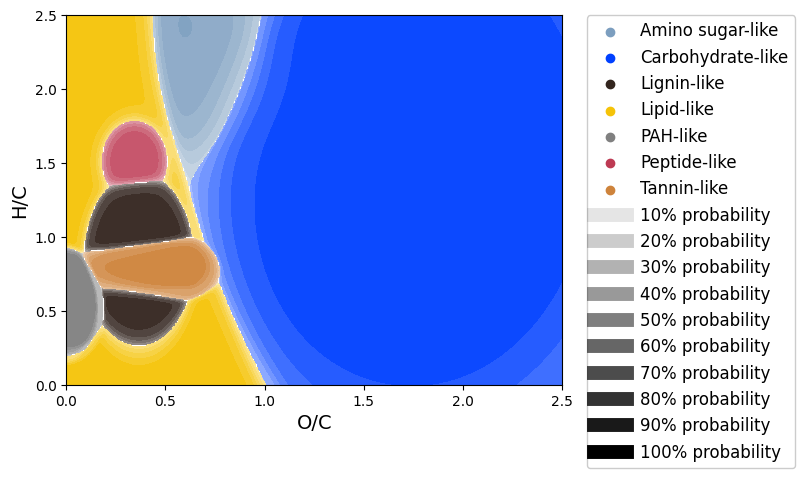

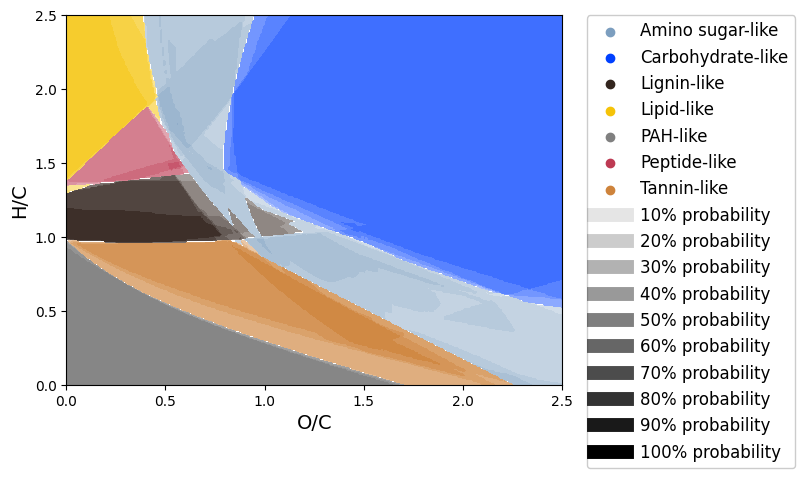

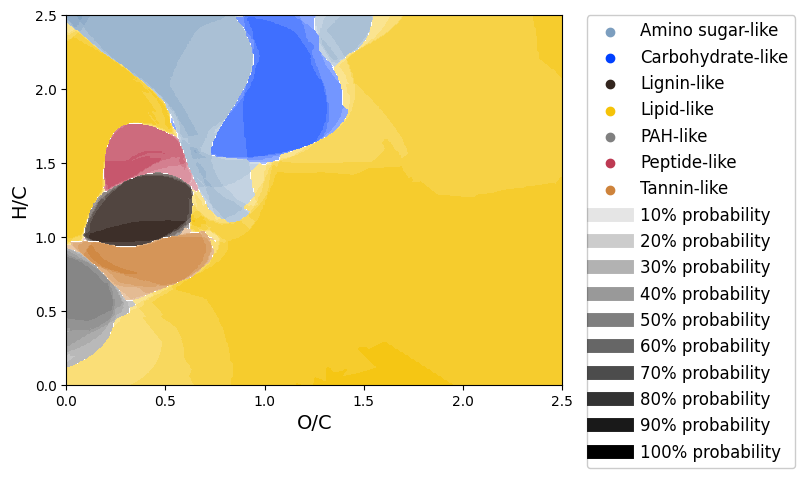

In [ ]:
# # check accuracy of SVC and GNB trained on 80% of the data with polynomial kernel degree found earlier
# gnb = CalibratedClassifierCV(GaussianNB())
# svc_poly = CalibratedClassifierCV(SVC(kernel="poly",
#                                  degree=poly_degree,
#                                  C=100, gamma=1,
#                                  probability=True))
# svc_rbf = CalibratedClassifierCV(SVC(kernel="rbf",
#                                 C=100, gamma=1,
#                                 probability=True))

# test_model_accuracy(gnb,X_complete,y_complete, classifier_name='GNB - complete',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)
# test_model_accuracy(svc_poly,X_complete,y_complete, classifier_name='SVC - poly - complete',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)
# test_model_accuracy(svc_rbf,X_complete,y_complete, classifier_name='SVC - rbf - complete',xlabel=wanted_columns_more[0],ylabel=wanted_columns_more[1],colors_dict=vk_region_colours)

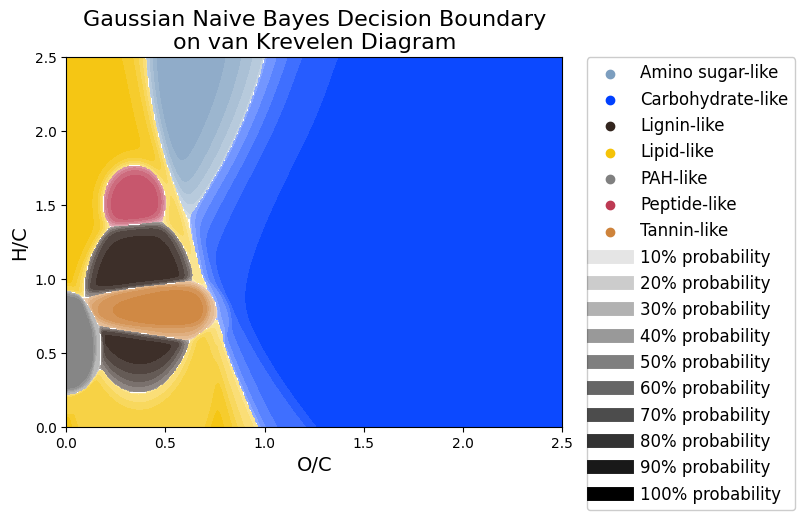

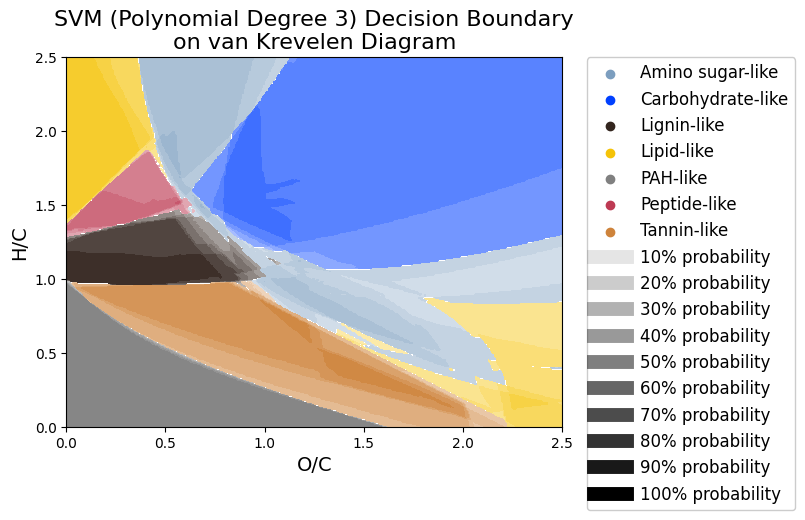

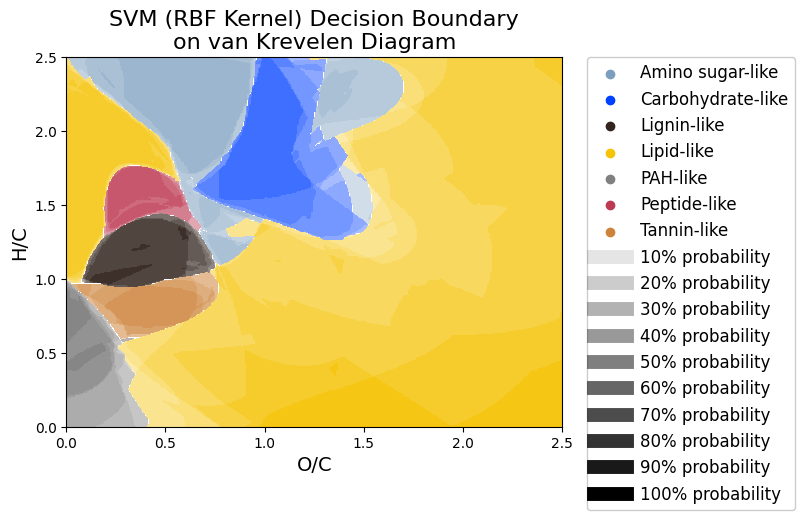

In [ ]:
# train both classifiers with the entire dataset
gnb_overall = CalibratedClassifierCV(GaussianNB()).fit(X_complete, y_complete, sample_weight=weights_complete if weighted else None)
svc_poly_overall = CalibratedClassifierCV(SVC(kernel="poly",degree=poly_degree,gamma='auto',probability=True)).fit(X_complete, y_complete, sample_weight=weights_complete if weighted else None)
svc_rbf_overall = CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1, probability=True)).fit(X_complete, y_complete, sample_weight=weights_complete if weighted else None)

draw_decision_boundary_plot(gnb_overall,
                            X_complete,
                            categories=np.unique(y_complete),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title='Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\gnb_vk_decision_boundary_all.svg',
                            colors_dict=vk_region_colours
                            )

draw_decision_boundary_plot(svc_poly_overall,
                            X_complete,
                            categories=np.unique(y_complete),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title=f'SVM (Polynomial Degree {poly_degree}) Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\svc_poly_vk_decision_boundary_all.svg',
                            colors_dict=vk_region_colours
                            )

draw_decision_boundary_plot(svc_rbf_overall,
                            X_complete,
                            categories=np.unique(y_complete),
                            xlabel=wanted_columns[0],
                            ylabel=wanted_columns[1],
                            title=f'SVM (RBF Kernel) Decision Boundary\non van Krevelen Diagram',
                            savepath='vk_definitions\\plots\\svc_rbf_vk_decision_boundary_all.svg',
                            colors_dict=vk_region_colours
                            )

In [35]:
# use more dimensions to train the classifiers
wanted_columns_more = ['O/C','H/C','N/C']
X_more_dims_complete = overall_df_complete[wanted_columns_more].to_numpy()

In [ ]:
# train both classifiers with the train-test split

gnb_more_dims = CalibratedClassifierCV(GaussianNB())
svc_poly_more_dims = CalibratedClassifierCV(SVC(kernel="poly",
                                           degree=poly_degree,
                                           C=100, gamma=1,
                                           probability=True))
svc_rbf_more_dims = CalibratedClassifierCV(SVC(kernel="rbf",
                                               C=100,
                                               gamma=1,
                                               probability=True))

test_model_accuracy(gnb_more_dims, X_more_dims_complete, y_complete, classifier_name='GNB - complete - 3 dims')
test_model_accuracy(svc_poly_more_dims, X_more_dims_complete, y_complete, classifier_name='SVC - complete - 3 dims')
test_model_accuracy(svc_rbf_more_dims, X_more_dims_complete, y_complete, classifier_name='SVC - complete - 3 dims')

Average accuracy of the GNB - complete - 3 dims classifier trained on 4861 samples (run 50 times): 0.9055682942696235 +/- 0.016896884719404797
Max accuracy: 0.9390162039840414
Min accuracy: 0.8425601717302788
Random Accuracy: 0.14285714285714285
Average accuracy of the SVC - complete - 3 dims classifier trained on 4861 samples (run 50 times): 0.9357158369269756 +/- 0.012532693948940205
Max accuracy: 0.9631188830418858
Min accuracy: 0.9057151208475582
Random Accuracy: 0.14285714285714285


In [41]:
# train both classifiers with the entire dataset
gnb_more_dims_all_complete = CalibratedClassifierCV(GaussianNB()).fit(X_more_dims_complete, y_complete, sample_weight=weights_complete if weighted else None)
svc_poly_more_dims_all_complete = CalibratedClassifierCV(SVC(kernel="poly",
                                                             degree=poly_degree,
                                                             C=100, gamma=1,
                                                             probability=True)).fit(X_more_dims_complete, y_complete, sample_weight=weights_complete if weighted else None)
svc_rbf_more_dims_all_complete = CalibratedClassifierCV(SVC(kernel="rbf",
                                                            C=100,
                                                            gamma=1,
                                                            probability=True)).fit(X_more_dims_complete, y_complete, sample_weight=weights_complete if weighted else None)

rndm_accuracy = 1/len(np.unique(y_complete))

# test model accuracy with the new dimensions
print(f'''Accuracy of the Gaussian Naive Bayes classifier trained on {len(X_more_dims_complete)} samples (more dimensions): {balanced_accuracy_score(y_true = y_complete,
                                                                                                                                          y_pred = gnb_more_dims_all_complete.predict(X_more_dims_complete),
                                                                                                                                          sample_weight=weights_complete if weighted else None,
                                                                                                                                          )
                                                                                                                    } 

Accuracy of the SVC classifier (Polynomial Degree {poly_degree}) trained on {len(X_more_dims_complete)} samples (more dimensions): {balanced_accuracy_score(y_true = y_complete,
                                                                                                                                                             y_pred = svc_poly_more_dims_all_complete.predict(X_more_dims_complete),
                                                                                                                                                             sample_weight=weights_complete if weighted else None,
                                                                                                                                                             )
                                                                                                                                    }

Accuracy of the SVC classifier (RBF Kernel) trained on {len(X_more_dims_complete)} samples (more dimensions): {balanced_accuracy_score(y_true = y_complete,
                                                                                                                                                             y_pred = svc_rbf_more_dims_all_complete.predict(X_more_dims_complete),
                                                                                                                                                             sample_weight=weights_complete if weighted else None,
                                                                                                                                                             )
                                                                                                                                    }                                                                                                                                    

Random Accuracy: {rndm_accuracy}''')


Accuracy of the Gaussian Naive Bayes classifier trained on 6077 samples (more dimensions): 0.9081187802768896 

Accuracy of the SVC classifier (Polynomial Degree 3) trained on 6077 samples (more dimensions): 0.9621174522982416

Accuracy of the SVC classifier (RBF Kernel) trained on 6077 samples (more dimensions): 0.9619219046313201                                                                                                                                    

Random Accuracy: 0.14285714285714285


In [ ]:
persist_model_onnx(gnb_more_dims_all_complete, X_more_dims_complete, "vk_definitions\\models\\gnb_complete.onnx")
persist_model_onnx(svc_poly_more_dims_all_complete, X_more_dims_complete, "vk_definitions\\models\\svc_complete.onnx")
persist_model_onnx(svc_rbf_more_dims_all_complete, X_more_dims_complete, "vk_definitions\\models\\svc_rbf_complete.onnx")

In [51]:
DecisionBoundaryDisplay_3D(X_more_dims_complete,
                           gnb_more_dims_all_complete,
                           dims=wanted_columns_more,
                           title='Gaussian Naive Bayes Decision Boundary\non van Krevelen Diagram - 3D',
                           savepath='vk_definitions\\plots\\gnb_vk_decision_boundary_3d_all.html',
                           show=False
                           )

DecisionBoundaryDisplay_3D(X_more_dims_complete,
                           svc_poly_more_dims_all_complete,
                           dims=wanted_columns_more,
                           title=f'SVC (Polynomial Degree {poly_degree}) Decision Boundary\non van Krevelen Diagram - 3D',
                           savepath='vk_definitions\\plots\\svc_vk_decision_boundary_3d_all.html',
                           show=False
                           )

DecisionBoundaryDisplay_3D(X_more_dims_complete,
                           svc_rbf_more_dims_all_complete,
                           dims=wanted_columns_more,
                           title=f'SVM (RBF Kernel) Decision Boundary\non van Krevelen Diagram - 3D',
                           savepath='vk_definitions\\plots\\svc_rbf_vk_decision_boundary_3d_all.html',
                           show=False
                           )

In [36]:
clf_models = {
    'GNB': CalibratedClassifierCV(GaussianNB()),
    'SVC (Polynomial)': CalibratedClassifierCV(SVC(kernel="poly", degree=poly_degree, gamma='auto')),
    'SVC (RBF)': CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1)),
}

complete_accuracies_dict = {name: [] for name in clf_models.keys()}
complete_balanced_accuracies_dict = {name: [] for name in clf_models.keys()}

repeats = 200

columns = wanted_columns_more

for n in range(repeats):
    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = train_test(X_more_dims_complete, y_complete,random_state=None)

    for model in clf_models:
        clf = clf_models[model].fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)
        y_pred = clf.predict(X_rdm_test)

        acc = accuracy_score(y_true=y_rdm_test,
                             y_pred=y_pred,
                             normalize=True)
        complete_accuracies_dict[model].append(acc)

        balanced_acc = balanced_accuracy_score(y_true=y_rdm_test,
                                               y_pred=y_pred,
                                               sample_weight=weights_rdm_test if weighted else None)
        complete_balanced_accuracies_dict[model].append(balanced_acc)

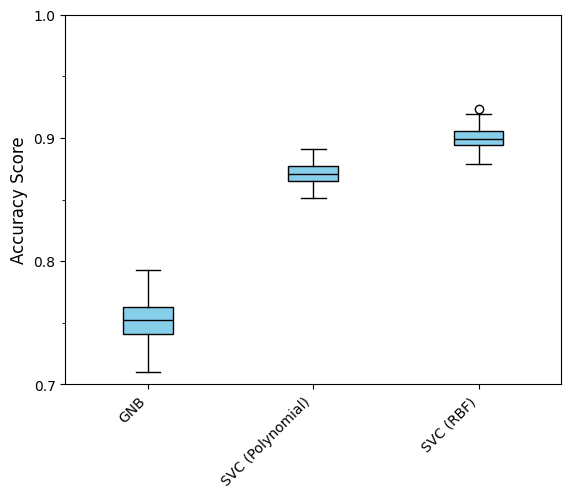

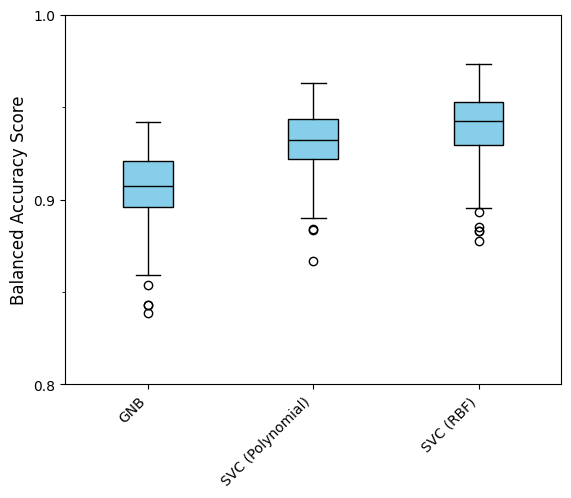

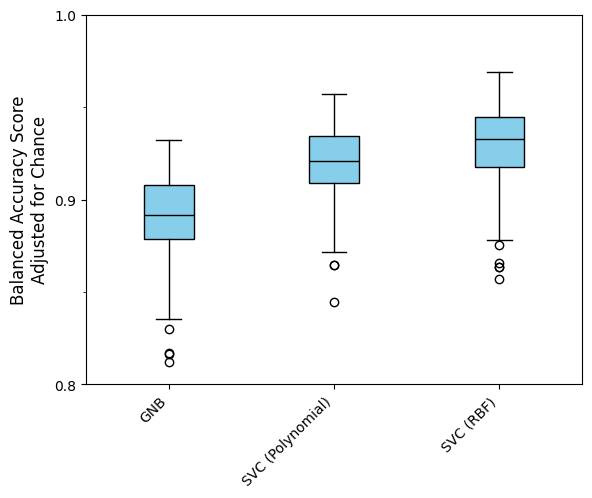

In [39]:
complete_chance_balanced_accuracies_dict = {}
for key in complete_balanced_accuracies_dict:
    number_of_categories = len(np.unique(y_complete))

    chance = 1 / number_of_categories

    complete_chance_balanced_accuracies_dict[key] = [(acc-chance)/(1 - chance) for acc in complete_balanced_accuracies_dict[key] ]

comparison_complete_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in clf_models.keys()],
    'mean_accuracy':[np.mean(complete_accuracies_dict[model]) for model in clf_models.keys()],
    'std_accuracy':[np.std(complete_accuracies_dict[model]) for model in clf_models.keys()],
    'median_accuracy':[np.median(complete_accuracies_dict[model]) for model in clf_models.keys()],
    'mean_balanced_accuracy':[np.mean(complete_balanced_accuracies_dict[model]) for model in clf_models.keys()],
    'std_balanced_accuracy':[np.std(complete_balanced_accuracies_dict[model]) for model in clf_models.keys()],
    'median_balanced_accuracy':[np.median(complete_balanced_accuracies_dict[model]) for model in clf_models.keys()],
    'mean_chance_balanced_accuracy':[np.mean(complete_chance_balanced_accuracies_dict[model]) for model in clf_models.keys()],
    'std_chance_balanced_accuracy':[np.std(complete_chance_balanced_accuracies_dict[model]) for model in clf_models.keys()],
    'median_chance_balanced_accuracy':[np.median(complete_chance_balanced_accuracies_dict[model]) for model in clf_models.keys()],
})

comparison_complete_df.to_csv('vk_definitions\\model_performance_comparison_all.csv', index=False)

draw_boxplot(complete_accuracies_dict,
             ylabel='Accuracy Score',
             colours=['skyblue'],
             savepath='vk_definitions\\plots\\comparison_boxplot_raw_all.svg')
draw_boxplot(complete_balanced_accuracies_dict,
             ylabel='Balanced Accuracy Score',
             colours=['skyblue'],
             savepath='vk_definitions\\plots\\comparison_boxplot_all.svg')
draw_boxplot(complete_chance_balanced_accuracies_dict,
             ylabel='Balanced Accuracy Score\nAdjusted for Chance',
             colours=['skyblue'],
             savepath='vk_definitions\\plots\\comparison_boxplot_adjusted_all.svg')

